# Logistic Regression - BODMAS Malware Classification


Logistic Regression was selected as the first classifier for several reasons:

- **High-dimensional suitability:** BODMAS feature vectors are high-dimensional numerical representations of PE binaries. Logistic Regression with L2 regularisation handles this well by penalising large coefficients and preventing overfitting.
- **Interpretable baseline:** It provides a strong, interpretable linear baseline to compare against more complex models like Random Forest.
- **SAGA solver:** The `saga` solver supports multinomial (softmax) loss, making it directly applicable to this multi-class problem without decomposing into binary classifiers.
- **Class imbalance:** `class_weight='balanced'` automatically adjusts decision boundaries to account for the skewed class distribution in BODMAS, where benign samples dominate.

In [ ]:
# ============================================================
# LOGISTIC REGRESSION NOTEBOOK
# Retraining on the official 100,000-sample training subset,
# ============================================================

import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

from google.colab import drive
drive.mount('/content/drive')

# =========================
# MAIN PROJECT PATH
# =========================
PROJECT_DIR = "/content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain"

# Main original dataset folder.
DATA_DIR = os.path.join(PROJECT_DIR, "dataset")

# Newly released holdout dataset folder.
HOLDOUT_DIR = os.path.join(PROJECT_DIR, "HoldOutDataSet")

OUTPUT_DIR = os.path.join(PROJECT_DIR, "logisticregression")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Original feature dataset used to extract the 100,000 official training rows.
BODMAS_NPZ = os.path.join(DATA_DIR, "bodmas.npz")

# Original metadata is used only to map SHA -> row index in bodmas.npz.
ORIGINAL_METADATA_CSV = os.path.join(DATA_DIR, "bodmas_metadata.csv")

# Official retraining subset metadata released with the holdout dataset.
TRAIN_TEST_METADATA_CSV = os.path.join(HOLDOUT_DIR, "bodmas_metadata_train_test.csv")

# Same malware category file released with the holdout dataset.
CATEGORY_CSV = os.path.join(HOLDOUT_DIR, "bodmas_malware_category.csv")

# Holdout files for final evaluation.
HOLDOUT_NPZ = os.path.join(HOLDOUT_DIR, "bodmas_holdout.npz")
HOLDOUT_METADATA_CSV = os.path.join(HOLDOUT_DIR, "bodmas_metadata_holdout.csv")

RANDOM_STATE = 42
TEST_SIZE = 0.20   # for internal validation

print("Original data folder:", DATA_DIR)
print("Holdout/retraining folder:", HOLDOUT_DIR)
print("Logistic Regression output folder:", OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original data folder: /content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain/dataset
Holdout/retraining folder: /content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain/HoldOutDataSet
Logistic Regression output folder: /content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain/logisticregression


## Data Loading

The BODMAS dataset consists of three files:
- `bodmas.npz` - the pre-extracted numerical feature matrix `X`
- `bodmas_metadata.csv` - SHA256 hashes and file-level metadata for all samples
- `bodmas_malware_category.csv` - maps SHA256 hashes to malware family labels (malware only)

These are loaded separately and joined on the SHA256 column in the next step.

## Label Preparation

The category CSV only contains malware samples - benign samples are absent by design. Labels are assigned by joining metadata with the category file on SHA256. Any sample not found in the category file is filled as `"benign"`. This correctly reconstructs the full ground-truth label set without discarding any samples.

The code also auto-detects whether the SHA column is named `sha` or `sha256` to handle potential schema differences between the training and holdout files.

In [ ]:
# ============================================================
# LOAD OFFICIAL 100,000-SAMPLE TRAINING SUBSET AND LABELS
# ============================================================

print("=" * 80)
print("LOADING OFFICIAL TRAINING SUBSET")
print("=" * 80)

# Load the original feature matrix.
data = np.load(BODMAS_NPZ, allow_pickle=True)
X_full = data["X"]

# Load official 100,000-row retraining metadata and category labels.
train_test_metadata = pd.read_csv(TRAIN_TEST_METADATA_CSV)
categories = pd.read_csv(CATEGORY_CSV)

print("NPZ keys:", list(data.keys()))
print("Original feature matrix shape:", X_full.shape)
print("Official train/test metadata shape:", train_test_metadata.shape)
print("Category file shape:", categories.shape)

print("\nOfficial train/test metadata columns:", train_test_metadata.columns.tolist())
print("Category columns:", categories.columns.tolist())

# =========================
# Select the official 100,000 samples
# =========================
train_sha_col = "sha256" if "sha256" in train_test_metadata.columns else "sha"

if os.path.exists(ORIGINAL_METADATA_CSV):
    original_metadata = pd.read_csv(ORIGINAL_METADATA_CSV)
    original_sha_col = "sha256" if "sha256" in original_metadata.columns else "sha"

    print("\nOriginal metadata shape:", original_metadata.shape)
    print("Using original metadata SHA column:", original_sha_col)
    print("Using train/test metadata SHA column:", train_sha_col)

    if X_full.shape[0] != original_metadata.shape[0]:
        raise ValueError(
            f"Original bodmas.npz rows ({X_full.shape[0]}) do not match original metadata rows "
            f"({original_metadata.shape[0]}). Check that bodmas.npz and bodmas_metadata.csv are from the same dataset."
        )

    sha_to_index = pd.Series(original_metadata.index.values, index=original_metadata[original_sha_col].astype(str))
    train_indices = train_test_metadata[train_sha_col].astype(str).map(sha_to_index)

    missing = train_indices.isna().sum()
    if missing > 0:
        missing_shas = train_test_metadata.loc[train_indices.isna(), train_sha_col].head(5).tolist()
        raise ValueError(f"{missing} train/test SHA values were not found in original metadata. Examples: {missing_shas}")

    train_indices = train_indices.astype(int).to_numpy()
    X = X_full[train_indices]
    df = train_test_metadata.copy().reset_index(drop=True)

else:
    # Fallback: only safe if the loaded feature matrix is already the 100,000-row training feature matrix.
    if X_full.shape[0] != train_test_metadata.shape[0]:
        raise FileNotFoundError(
            "Original bodmas_metadata.csv is required to map the 100,000 official training SHA values "
            "to rows in the full bodmas.npz. Put bodmas_metadata.csv in DATA_DIR, or provide a "
            "100,000-row feature NPZ already aligned with bodmas_metadata_train_test.csv."
        )
    print("\nOriginal metadata not found, but feature rows already match official train/test metadata rows.")
    X = X_full
    df = train_test_metadata.copy().reset_index(drop=True)

# =========================
# Correct label preparation
# =========================
metadata_sha_col = train_sha_col
category_sha_col = "sha256" if "sha256" in categories.columns else "sha"

possible_category_cols = [
    col for col in categories.columns
    if col.lower() not in ["sha", "sha256"]
]
category_label_col = possible_category_cols[0]

print("\nUsing training SHA column:", metadata_sha_col)
print("Using category SHA column:", category_sha_col)
print("Using malware category column:", category_label_col)

category_map = categories.set_index(category_sha_col)[category_label_col]

df["malware_category"] = df[metadata_sha_col].astype(str).map(category_map)

# The category CSV does not include benign samples.
df["malware_category"] = df["malware_category"].fillna("benign")

y_text = df["malware_category"].astype(str).values

print("\nOfficial retraining X shape:", X.shape)
print("Official retraining y shape:", y_text.shape)

if X.shape[0] != 100000:
    print("WARNING: Expected 100,000 official retraining rows, but got", X.shape[0])
else:
    print("Confirmed: using the official 100,000-sample retraining subset.")

print("\nOfficial retraining class distribution:")
class_distribution = pd.Series(y_text).value_counts()
display(class_distribution)

class_distribution.to_csv(os.path.join(OUTPUT_DIR, "class_distribution_official_train_test_subset.csv"))

LOADING OFFICIAL TRAINING SUBSET
NPZ keys: ['X', 'y']
Original feature matrix shape: (134435, 2381)
Official train/test metadata shape: (100000, 3)
Category file shape: (57293, 2)

Official train/test metadata columns: ['sha', 'timestamp', 'family']
Category columns: ['sha256', 'category']

Original metadata shape: (134435, 3)
Using original metadata SHA column: sha
Using train/test metadata SHA column: sha

Using training SHA column: sha
Using category SHA column: sha256
Using malware category column: category

Official retraining X shape: (100000, 2381)
Official retraining y shape: (100000,)
Confirmed: using the official 100,000-sample retraining subset.

Official retraining class distribution:


,count
benign,58779
trojan,23248
worm,10552
backdoor,4665
downloader,976
ransomware,716
dropper,580
informationstealer,231
virus,192
pua,20


## Label Encoding and Train-Test Split

Class names (strings) are converted to integer indices using `LabelEncoder`. The encoder is saved to disk so the holdout evaluation uses identical class-to-index mappings without refitting.

An **80/20 stratified split** is used to ensure each malware family is proportionally represented in both train and test sets. `random_state=42` ensures reproducibility.

In [ ]:
# ============================================================
# LABEL ENCODING AND INTERNAL VALIDATION SPLIT
# ============================================================

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

class_names = list(label_encoder.classes_)

print("Classes:")
for idx, name in enumerate(class_names):
    print(idx, "->", name)

# Save label encoder for holdout evaluation.
joblib.dump(label_encoder, os.path.join(OUTPUT_DIR, "label_encoder.joblib"))

# Keep a copy of the full official training subset for final retraining.
X_train_full = X
y_train_full = y

X_train, X_test, y_train, y_test = train_test_split(
    X_train_full,
    y_train_full,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print("\nOfficial full retraining shape:", X_train_full.shape)
print("Internal model-training shape:", X_train.shape)
print("Internal validation shape:", X_test.shape)

print("\nOfficial full retraining class distribution:")
display(pd.Series(label_encoder.inverse_transform(y_train_full)).value_counts())

print("\nInternal model-training class distribution:")
display(pd.Series(label_encoder.inverse_transform(y_train)).value_counts())

print("\nInternal validation class distribution:")
display(pd.Series(label_encoder.inverse_transform(y_test)).value_counts())

Classes:
0 -> backdoor
1 -> benign
2 -> cryptominer
3 -> downloader
4 -> dropper
5 -> exploit
6 -> informationstealer
7 -> p2p-worm
8 -> pua
9 -> ransomware
10 -> rootkit
11 -> trojan
12 -> trojan-gamethief
13 -> virus
14 -> worm

Official full retraining shape: (100000, 2381)
Internal model-training shape: (80000, 2381)
Internal validation shape: (20000, 2381)

Official full retraining class distribution:


,count
benign,58779
trojan,23248
worm,10552
backdoor,4665
downloader,976
ransomware,716
dropper,580
informationstealer,231
virus,192
pua,20



Internal model-training class distribution:


,count
benign,47023
trojan,18598
worm,8442
backdoor,3732
downloader,781
ransomware,573
dropper,464
informationstealer,185
virus,154
pua,16



Internal validation class distribution:


,count
benign,11756
trojan,4650
worm,2110
backdoor,933
downloader,195
ransomware,143
dropper,116
informationstealer,46
virus,38
pua,4


## Evaluation Helper Functions

Two helper functions are defined here and reused throughout:

- `calculate_tpr_fpr` - computes per-class True Positive Rate (TPR = TP / (TP + FN)) and False Positive Rate (FPR = FP / (FP + TN)) using a one-vs-rest breakdown of the confusion matrix.
- `evaluate_model` - runs prediction on a given split, prints overall accuracy, balanced accuracy, the full classification report, and calls `calculate_tpr_fpr` for per-class detail.

Balanced accuracy is reported alongside overall accuracy because the BODMAS dataset is class-imbalanced - overall accuracy alone would be misleading.

In [ ]:
# ============================================================
# EVALUATION HELPER FUNCTIONS
# ============================================================

def calculate_tpr_fpr(y_true, y_pred, class_names):
    """
    One-vs-rest TPR and FPR for each class.

    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)
    """
    labels = np.arange(len(class_names))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    rows = []

    for i, class_name in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        rows.append({
            "class": class_name,
            "TP": TP,
            "FP": FP,
            "TN": TN,
            "FN": FN,
            "TPR": TPR,
            "FPR": FPR
        })

    return pd.DataFrame(rows)


def evaluate_model(model, X_data, y_data, split_name):
    print("=" * 80)
    print(f"LOGISTIC REGRESSION EVALUATION ON {split_name.upper()}")
    print("=" * 80)

    y_pred = model.predict(X_data)

    accuracy = accuracy_score(y_data, y_pred)
    balanced_acc = balanced_accuracy_score(y_data, y_pred)

    print("Overall Accuracy:", round(accuracy, 4))
    print("Balanced Accuracy:", round(balanced_acc, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_data,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))

    tpr_fpr_df = calculate_tpr_fpr(y_data, y_pred, class_names)

    print("\nTPR and FPR per class:")
    display(tpr_fpr_df)

    return {
        "split": split_name,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "predictions": y_pred,
        "tpr_fpr": tpr_fpr_df
    }

## Hyperparameter Tuning

`RandomizedSearchCV` is used instead of `GridSearchCV` because the search space, while small for LR, is evaluated more efficiently with random sampling - especially important given the size of the BODMAS dataset.

Tuning is performed on a **25% stratified subsample** of the training data to reduce wall-clock time. The full training set is used only for the final model fit. 2-fold cross-validation is used as a pragmatic trade-off between variance estimation and runtime.

The key hyperparameter being tuned is **C** (inverse regularisation strength). Smaller C = stronger regularisation. The search space `[0.01, 0.05, 0.1, 0.5, 1, 3, 10]` spans three orders of magnitude to identify the right bias-variance trade-off for this feature space.

Scoring is based on **balanced accuracy** to avoid the metric being dominated by the benign majority class.

In [ ]:
# ============================================================
# LOGISTIC REGRESSION HYPERPARAMETER TUNING
# ============================================================

TUNE_SIZE = 0.25

X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=TUNE_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Tuning subset shape:", X_tune.shape)

lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        random_state=RANDOM_STATE,
        solver="saga",
        penalty="l2",
        multi_class="multinomial",
        class_weight="balanced",
        max_iter=300,
        n_jobs=-1
    ))
])

lr_param_grid = {
    "classifier__C": [0.01, 0.05, 0.1, 0.5, 1, 3, 10]
}

lr_search = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=lr_param_grid,
    n_iter=7,
    scoring="balanced_accuracy",
    cv=2,
    verbose=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

start_time = time.time()

lr_search.fit(X_tune, y_tune)

end_time = time.time()

print("\nLogistic Regression tuning completed.")
print("Tuning time:", round((end_time - start_time) / 60, 2), "minutes")
print("Best parameters:")
print(lr_search.best_params_)
print("Best CV balanced accuracy:", lr_search.best_score_)

Tuning subset shape: (20000, 2381)
Fitting 2 folds for each of 7 candidates, totalling 14 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression tuning completed.
Tuning time: 35.78 minutes
Best parameters:
{'classifier__C': 0.01}
Best CV balanced accuracy: 0.7320759882149653


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Final Model Training

The final pipeline is trained on the **complete training split** using the best hyperparameter found during tuning (`C=1`).

The pipeline applies three preprocessing steps before the classifier:
1. **`SimpleImputer(strategy='median')`** - fills any missing feature values with the column median. Median is preferred over mean as it is robust to outlier feature values common in PE binary analysis.
2. **`VarianceThreshold()`** - removes constant (zero-variance) features that carry no discriminative information. PE feature extractors often produce many such columns.
3. **`StandardScaler()`** - standardises features to zero mean and unit variance. This is essential for Logistic Regression as the SAGA solver's gradient updates are sensitive to feature scale; unscaled features cause slow or failed convergence.

`max_iter=500` is set to ensure the SAGA solver converges on this high-dimensional dataset.

In [ ]:
# ============================================================
# TRAIN FINAL LOGISTIC REGRESSION MODEL
# ============================================================

best_params = lr_search.best_params_

lr_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        random_state=RANDOM_STATE,
        solver="saga",
        penalty="l2",
        multi_class="multinomial",
        class_weight="balanced",
        max_iter=500,
        n_jobs=-1,
        C=best_params["classifier__C"]
    ))
])

print("=" * 80)
print("RETRAINING FINAL LOGISTIC REGRESSION MODEL ON OFFICIAL 100,000-SAMPLE SUBSET")
print("=" * 80)

start_time = time.time()

lr_final.fit(X_train_full, y_train_full)

end_time = time.time()

training_time_minutes = round((end_time - start_time) / 60, 2)

print("Training completed.")
print("Training time:", training_time_minutes, "minutes")

# Save final model
model_path = os.path.join(OUTPUT_DIR, "logistic_regression_model.joblib")
joblib.dump(lr_final, model_path)

print("Saved model to:", model_path)

# Save best hyperparameters
best_params_path = os.path.join(OUTPUT_DIR, "logistic_regression_best_params.txt")

with open(best_params_path, "w") as f:
    f.write(str(best_params))
    f.write("\n")
    f.write("Best CV balanced accuracy: " + str(lr_search.best_score_))
    f.write("\n")
    f.write("Training time minutes: " + str(training_time_minutes))

print("Saved best parameters to:", best_params_path)

RETRAINING FINAL LOGISTIC REGRESSION MODEL ON OFFICIAL 100,000-SAMPLE SUBSET


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training completed.
Training time: 132.24 minutes
Saved model to: /content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain/logisticregression/logistic_regression_model.joblib
Saved best parameters to: /content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain/logisticregression/logistic_regression_best_params.txt


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Model Evaluation - Train and Test Splits

The trained model is evaluated on both the training and test splits. Evaluating on the training set helps detect overfitting; the test set gives an unbiased estimate of generalisation performance.

Metrics reported:
- **Overall Accuracy** - fraction of correctly classified samples
- **Balanced Accuracy** - mean recall across classes, accounts for class imbalance
- **Classification Report** - per-class precision, recall, F1
- **TPR and FPR per class** - one-vs-rest breakdown saved to CSV for further analysis

In [ ]:
# ============================================================
# EVALUATE LOGISTIC REGRESSION
# ============================================================

lr_train_results = evaluate_model(
    lr_final,
    X_train_full,
    y_train_full,
    "official 100,000-sample training subset"
)

lr_test_results = evaluate_model(
    lr_final,
    X_test,
    y_test,
    "internal validation set"
)

# Saving TPR/FPR results
lr_train_results["tpr_fpr"].to_csv(
    os.path.join(OUTPUT_DIR, "lr_train_tpr_fpr.csv"),
    index=False
)

lr_test_results["tpr_fpr"].to_csv(
    os.path.join(OUTPUT_DIR, "lr_test_tpr_fpr.csv"),
    index=False
)

lr_summary = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "split": "official_train_subset",
        "accuracy": lr_train_results["accuracy"],
        "balanced_accuracy": lr_train_results["balanced_accuracy"]
    },
    {
        "model": "Logistic Regression",
        "split": "internal_validation",
        "accuracy": lr_test_results["accuracy"],
        "balanced_accuracy": lr_test_results["balanced_accuracy"]
    }
])

display(lr_summary)

lr_summary.to_csv(
    os.path.join(OUTPUT_DIR, "lr_results_summary.csv"),
    index=False
)

LOGISTIC REGRESSION EVALUATION ON OFFICIAL 100,000-SAMPLE TRAINING SUBSET
Overall Accuracy: 0.9094
Balanced Accuracy: 0.9002

Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.88      0.97      0.92      4665
            benign       0.99      0.95      0.97     58779
       cryptominer       0.17      1.00      0.29        19
        downloader       0.37      0.97      0.54       976
           dropper       0.36      0.93      0.51       580
           exploit       0.50      1.00      0.67        12
informationstealer       0.20      0.97      0.34       231
          p2p-worm       0.00      0.00      0.00         3
               pua       0.08      1.00      0.15        20
        ransomware       0.53      0.98      0.69       716
           rootkit       0.14      1.00      0.24         3
            trojan       0.92      0.77      0.84     23248
  trojan-gamethief       0.03      1.00      0.06         4
          

,class,TP,FP,TN,FN,TPR,FPR
0,backdoor,4526,612,94723,139,0.970204,0.006419
1,benign,55725,342,40879,3054,0.948043,0.008297
2,cryptominer,19,94,99887,0,1.000000,0.000940
3,downloader,948,1617,97407,28,0.971311,0.016329
4,dropper,539,979,98441,41,0.929310,0.009847
5,exploit,12,12,99976,0,1.000000,0.000120
6,informationstealer,225,879,98890,6,0.974026,0.008810
7,p2p-worm,0,38,99959,3,0.000000,0.000380
8,pua,20,229,99751,0,1.000000,0.002290
9,ransomware,703,627,98657,13,0.981844,0.006315


LOGISTIC REGRESSION EVALUATION ON INTERNAL VALIDATION SET
Overall Accuracy: 0.9086
Balanced Accuracy: 0.9025

Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.89      0.98      0.93       933
            benign       0.99      0.94      0.97     11756
       cryptominer       0.20      1.00      0.33         4
        downloader       0.39      0.98      0.56       195
           dropper       0.36      0.95      0.52       116
           exploit       0.50      1.00      0.67         2
informationstealer       0.21      0.98      0.34        46
          p2p-worm       0.00      0.00      0.00         1
               pua       0.07      1.00      0.13         4
        ransomware       0.53      0.98      0.68       143
           rootkit       0.20      1.00      0.33         1
            trojan       0.91      0.78      0.84      4650
  trojan-gamethief       0.04      1.00      0.08         1
             virus       0

,class,TP,FP,TN,FN,TPR,FPR
0,backdoor,910,115,18952,23,0.975348,0.006031
1,benign,11109,69,8175,647,0.944964,0.008370
2,cryptominer,4,16,19980,0,1.000000,0.000800
3,downloader,192,295,19510,3,0.984615,0.014895
4,dropper,110,196,19688,6,0.948276,0.009857
5,exploit,2,2,19996,0,1.000000,0.000100
6,informationstealer,45,172,19782,1,0.978261,0.008620
7,p2p-worm,0,9,19990,1,0.000000,0.000450
8,pua,4,54,19942,0,1.000000,0.002701
9,ransomware,140,126,19731,3,0.979021,0.006345


,model,split,accuracy,balanced_accuracy
0,Logistic Regression,official_train_subset,0.90942,0.900206
1,Logistic Regression,internal_validation,0.90860,0.902503


## Confusion Matrices

Two confusion matrices are plotted for the test set:
- **Raw counts** - shows absolute prediction volumes per class pair
- **Row-normalised** - normalises each row by the true class count, making it easier to spot which classes are being confused with each other regardless of class size

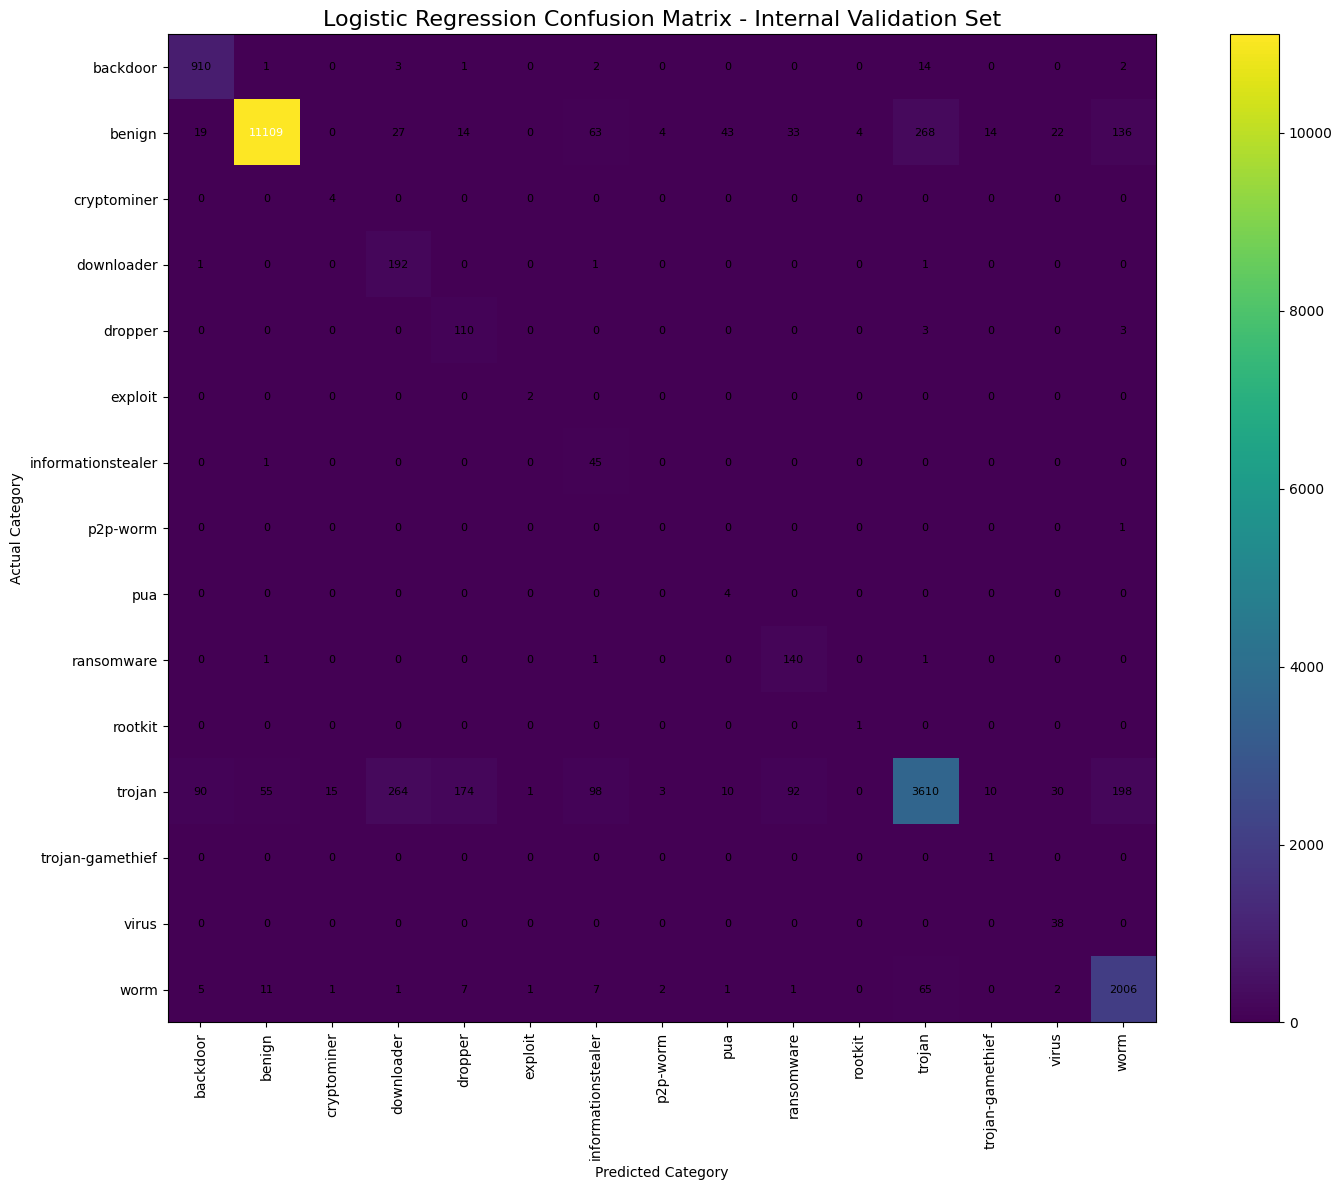

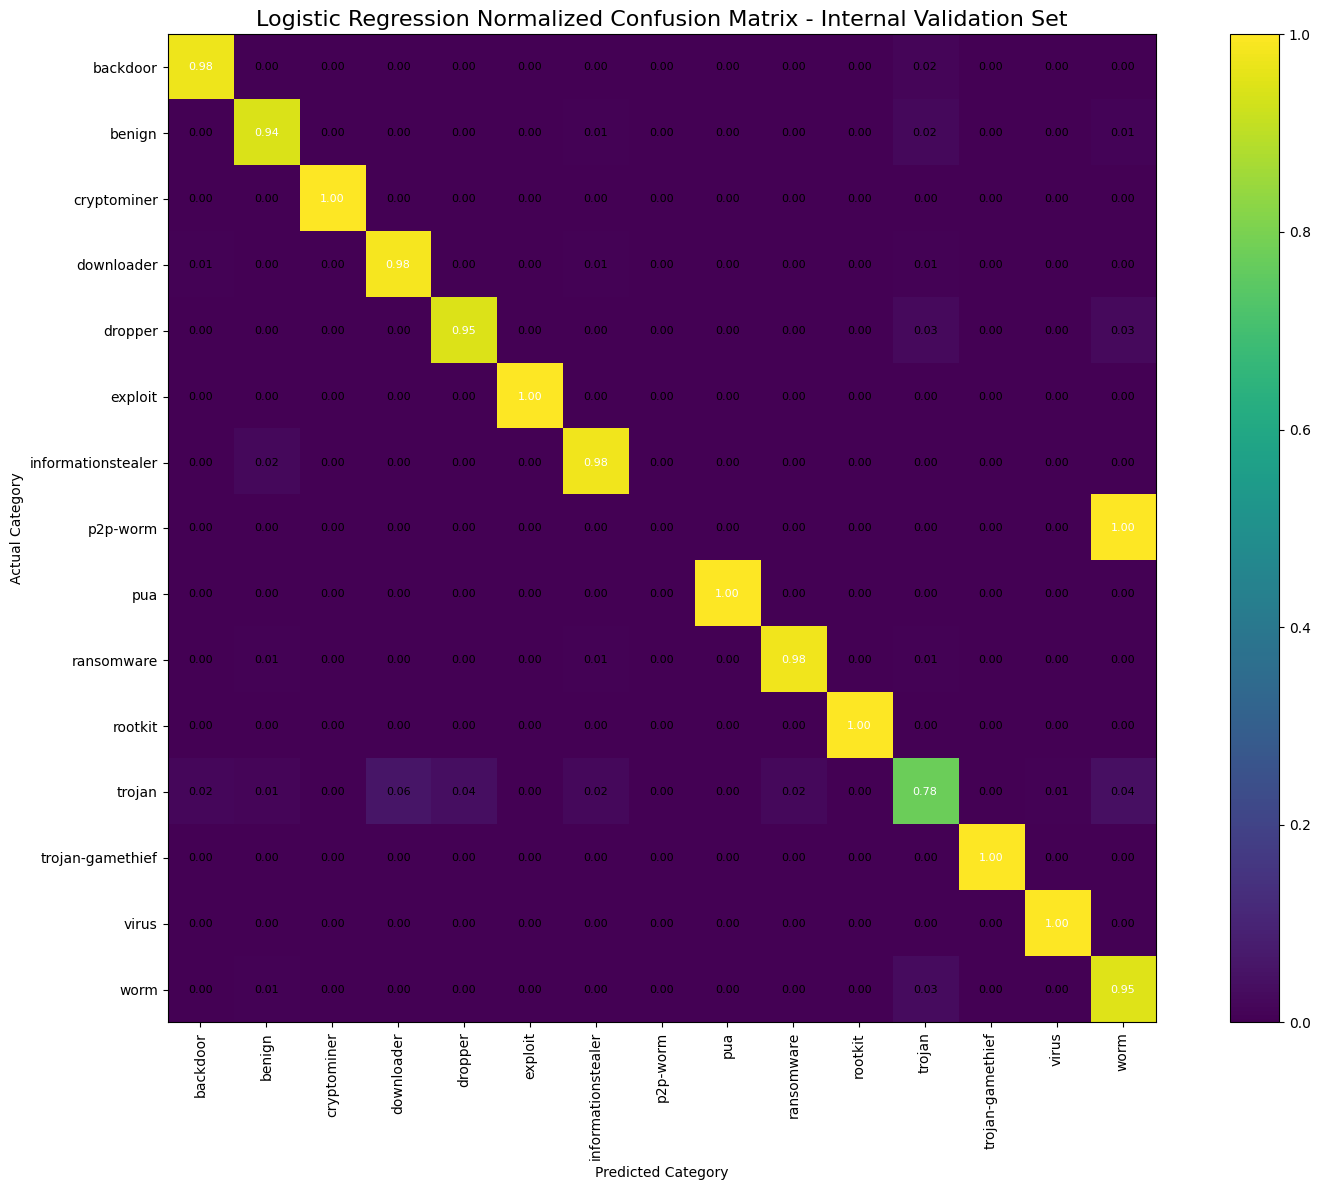

In [ ]:
# ============================================================
# CONFUSION MATRIX IMAGES
# ============================================================

def plot_confusion_matrix_image(y_true, y_pred, title, normalize=False):
    labels = np.arange(len(class_names))

    if normalize:
        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=labels,
            normalize="true"
        )
        fmt = ".2f"
    else:
        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=labels
        )
        fmt = "d"

    plt.figure(figsize=(16, 12))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title, fontsize=16)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=90)
    plt.yticks(tick_marks, class_names)

    threshold = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = format(cm[i, j], fmt)
            plt.text(
                j,
                i,
                value,
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
                fontsize=8
            )

    plt.ylabel("Actual Category")
    plt.xlabel("Predicted Category")
    plt.tight_layout()
    plt.show()


# Internal validation confusion matrix
plot_confusion_matrix_image(
    y_test,
    lr_test_results["predictions"],
    "Logistic Regression Confusion Matrix - Internal Validation Set",
    normalize=False
)

# Normalized internal validation confusion matrix
plot_confusion_matrix_image(
    y_test,
    lr_test_results["predictions"],
    "Logistic Regression Normalized Confusion Matrix - Internal Validation Set",
    normalize=True
)

## Sample Prediction Check

A sanity check on 30 randomly selected samples from the full dataset. This verifies the model produces sensible predictions on individual examples and confirms the label encoder round-trips correctly between integer indices and class name strings.

In [ ]:
# ============================================================
# CHECK LOGISTIC REGRESSION ON OFFICIAL TRAINING SUBSET SAMPLES
# ============================================================

N_SAMPLES = 30
rng = np.random.default_rng(RANDOM_STATE)

sample_indices = rng.choice(X_train_full.shape[0], size=N_SAMPLES, replace=False)

X_sample = X_train_full[sample_indices]
y_sample_true = y_train_full[sample_indices]

lr_sample_pred = lr_final.predict(X_sample)

sample_results = pd.DataFrame({
    "sample_index_in_official_train_subset": sample_indices,
    "sha": df.iloc[sample_indices][metadata_sha_col].values,
    "actual_category": label_encoder.inverse_transform(y_sample_true),
    "predicted_category": label_encoder.inverse_transform(lr_sample_pred),
})

sample_results["correct"] = (
    sample_results["actual_category"] == sample_results["predicted_category"]
)

display(sample_results)

sample_accuracy = accuracy_score(y_sample_true, lr_sample_pred)

print("Logistic Regression accuracy on selected official training samples:", round(sample_accuracy, 4))
print("Correct predictions:", sample_results["correct"].sum(), "/", N_SAMPLES)

,sample_index_in_official_train_subset,sha,actual_category,predicted_category,correct
0,64383,2ba3a0aa2477f2d2791619210171f8d99b84769efd89aa...,benign,benign,True
1,52637,8fee90e450f46c05140b6977c7303fd7a51caa29d64e99...,benign,benign,True
2,43290,7622fbd0a6f7dadd355dbea5d035fb706cb63cb5313b95...,benign,benign,True
3,85839,0018fd7efe382ad6716cf912d1aada3b193fcdfcbf60c2...,benign,benign,True
4,8922,358ab919eba1ffcfe81ed032053621d1b85ac83cce9d66...,benign,benign,True
5,9415,9939d8537385e5f26f4f08d6819858ca2d51044d92e542...,benign,benign,True
6,18253,f5b40ef73feec5f0420a1025a5c930a823ba2cc67beefb...,backdoor,backdoor,True
7,82274,7bc6f2e70fcc55f07c9a1b4fe8752d9369a8d8ec313f43...,benign,benign,True
8,78595,7b2103a8a24a9af05fec074008a2f6cb6918b235a24ca6...,trojan,trojan,True
9,69721,361812db5d2eb3b137c457a69ab007f5caa0773c88c758...,benign,benign,True


Logistic Regression accuracy on selected official training samples: 0.9667
Correct predictions: 29 / 30


## Holdout Dataset Evaluation

The trained Logistic Regression model and label encoder are loaded from disk. The holdout dataset is an entirely separate set of samples not seen during training or tuning.

Label preparation follows the same logic as training - SHA256 join with benign fill. A validation check raises an error if any holdout class was not present during training, preventing silent mismatch errors.

Results on the holdout set reflect real-world generalisation performance.

LR model: /content/drive/MyDrive/BODMAS_Assignment_Final/logisticregression/logistic_regression_model.joblib
Label encoder: /content/drive/MyDrive/BODMAS_Assignment_Final/logisticregression/label_encoder.joblib
Holdout NPZ: /content/drive/MyDrive/BODMAS_Assignment_Final/HoldOutDataSet/bodmas_holdout.npz

Logistic Regression model loaded.
Classes: ['backdoor', 'benign', 'cryptominer', 'downloader', 'dropper', 'exploit', 'informationstealer', 'p2p-worm', 'pua', 'ransomware', 'rootkit', 'trojan', 'trojan-gamethief', 'virus', 'worm']

Holdout X shape: (34435, 2381)
Holdout metadata shape: (34435, 3)
Holdout category shape: (57293, 2)

Holdout class distribution:


,count
benign,18363
trojan,6724
worm,6145
backdoor,2666
informationstealer,217
dropper,135
ransomware,105
downloader,55
p2p-worm,13
pua,9



Encoded holdout y shape: (34435,)

Running Logistic Regression on holdout dataset...

LOGISTIC REGRESSION HOLDOUT RESULTS
Overall Accuracy: 0.9095
Balanced Accuracy: 0.9513

Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.94      0.97      0.96      2666
            benign       1.00      0.97      0.98     18363
       cryptominer       0.08      1.00      0.15         1
        downloader       0.23      0.95      0.37        55
           dropper       0.38      0.98      0.55       135
           exploit       0.00      0.00      0.00         0
informationstealer       0.63      0.99      0.77       217
          p2p-worm       0.01      1.00      0.02        13
               pua       0.03      1.00      0.05         9
        ransomware       0.45      0.94      0.61       105
           rootkit       0.00      0.00      0.00         0
            trojan       0.94      0.80      0.86      6724
  trojan-gamethief   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,class,TP,FP,TN,FN,TPR,FPR
0,backdoor,2593,167,31602,73,0.972618,0.005257
1,benign,17811,84,15988,552,0.969940,0.005226
2,cryptominer,1,11,34423,0,1.000000,0.000319
3,downloader,52,171,34209,3,0.945455,0.004974
4,dropper,132,211,34089,3,0.977778,0.006152
5,exploit,0,1,34434,0,0.000000,0.000029
6,informationstealer,215,127,34091,2,0.990783,0.003711
7,p2p-worm,13,1105,33317,0,1.000000,0.032102
8,pua,9,336,34090,0,1.000000,0.009760
9,ransomware,99,121,34209,6,0.942857,0.003525


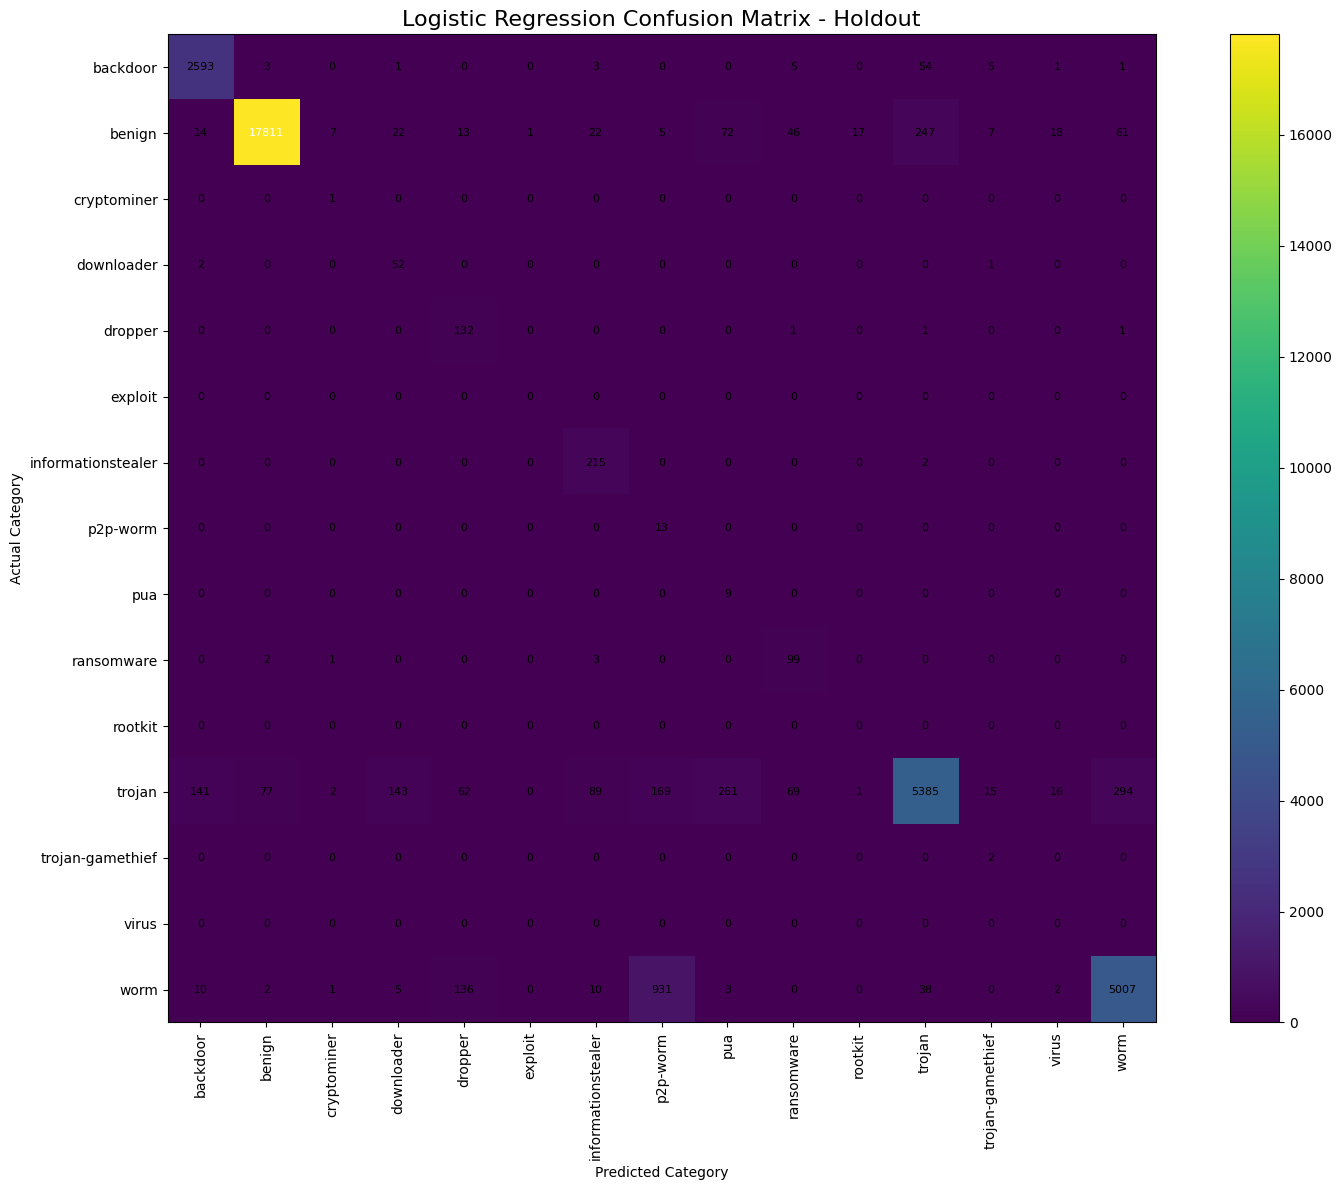

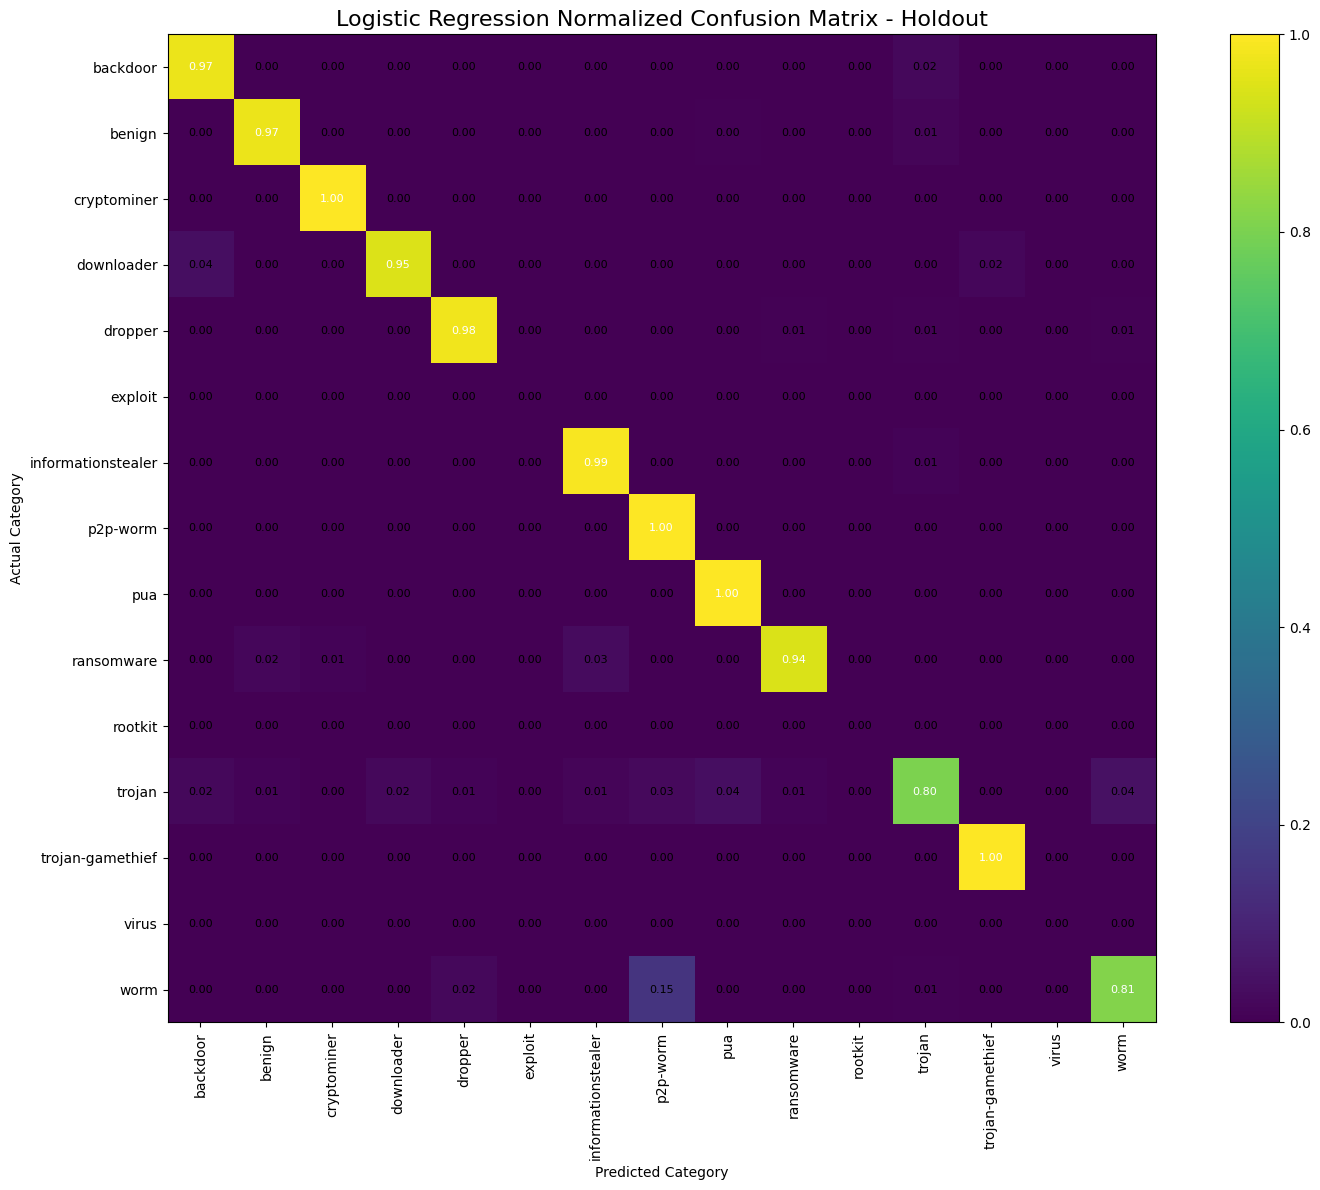

,model,split,trained_on,accuracy,balanced_accuracy
0,Logistic Regression,official_holdout,official_100000_train_test_subset,0.909511,0.951258


Saved holdout predictions to: /content/drive/MyDrive/BODMAS_Assignment_Final/logisticregression/lr_holdout_predictions.csv
Saved holdout TPR/FPR to: /content/drive/MyDrive/BODMAS_Assignment_Final/logisticregression/lr_holdout_tpr_fpr.csv
Saved holdout summary to: /content/drive/MyDrive/BODMAS_Assignment_Final/logisticregression/lr_holdout_results_summary.csv


In [ ]:
# ============================================================
# LOGISTIC REGRESSION - HOLDOUT DATASET EVALUATION
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain"

HOLDOUT_DIR = os.path.join(PROJECT_DIR, "HoldOutDataSet")
LR_DIR = os.path.join(PROJECT_DIR, "logisticregression")

HOLDOUT_NPZ = os.path.join(HOLDOUT_DIR, "bodmas_holdout.npz")
HOLDOUT_METADATA_CSV = os.path.join(HOLDOUT_DIR, "bodmas_metadata_holdout.csv")
HOLDOUT_CATEGORY_CSV = os.path.join(HOLDOUT_DIR, "bodmas_malware_category.csv")

LR_MODEL_PATH = os.path.join(LR_DIR, "logistic_regression_model.joblib")
LABEL_ENCODER_PATH = os.path.join(LR_DIR, "label_encoder.joblib")

print("LR model:", LR_MODEL_PATH)
print("Label encoder:", LABEL_ENCODER_PATH)
print("Holdout NPZ:", HOLDOUT_NPZ)

# ============================================================
# LOAD TRAINED LOGISTIC REGRESSION MODEL
# ============================================================

lr_model = joblib.load(LR_MODEL_PATH)
label_encoder = joblib.load(LABEL_ENCODER_PATH)

class_names = list(label_encoder.classes_)

print("\nLogistic Regression model loaded.")
print("Classes:", class_names)

# ============================================================
# LOAD HOLDOUT DATA
# ============================================================

holdout_data = np.load(HOLDOUT_NPZ, allow_pickle=True)
X_holdout = holdout_data["X"]

holdout_metadata = pd.read_csv(HOLDOUT_METADATA_CSV)
holdout_categories = pd.read_csv(HOLDOUT_CATEGORY_CSV)

print("\nHoldout X shape:", X_holdout.shape)
print("Holdout metadata shape:", holdout_metadata.shape)
print("Holdout category shape:", holdout_categories.shape)

# ============================================================
# PREPARE HOLDOUT CATEGORY LABELS
# ============================================================

metadata_sha_col = "sha256" if "sha256" in holdout_metadata.columns else "sha"
category_sha_col = "sha256" if "sha256" in holdout_categories.columns else "sha"

category_label_col = [
    c for c in holdout_categories.columns
    if c.lower() not in ["sha", "sha256"]
][0]

category_map = holdout_categories.set_index(category_sha_col)[category_label_col]

holdout_df = holdout_metadata.copy()
holdout_df["malware_category"] = holdout_df[metadata_sha_col].map(category_map)

# Missing category means benign
holdout_df["malware_category"] = holdout_df["malware_category"].fillna("benign")

y_holdout_text = holdout_df["malware_category"].astype(str).values

print("\nHoldout class distribution:")
display(pd.Series(y_holdout_text).value_counts())

# Check unknown labels
unknown_classes = set(y_holdout_text) - set(class_names)

if unknown_classes:
    raise ValueError(f"Unknown classes in holdout not seen during training: {unknown_classes}")

y_holdout = label_encoder.transform(y_holdout_text)

print("\nEncoded holdout y shape:", y_holdout.shape)

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def calculate_tpr_fpr(y_true, y_pred, class_names):
    labels = np.arange(len(class_names))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    rows = []

    for i, class_name in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        rows.append({
            "class": class_name,
            "TP": TP,
            "FP": FP,
            "TN": TN,
            "FN": FN,
            "TPR": TPR,
            "FPR": FPR
        })

    return pd.DataFrame(rows)


def plot_confusion_matrix_image(y_true, y_pred, title, normalize=False):
    labels = np.arange(len(class_names))

    if normalize:
        cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
        fmt = ".2f"
    else:
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        fmt = "d"

    plt.figure(figsize=(16, 12))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title, fontsize=16)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=90)
    plt.yticks(tick_marks, class_names)

    threshold = cm.max() / 2 if cm.max() > 0 else 0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                format(cm[i, j], fmt),
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
                fontsize=8
            )

    plt.ylabel("Actual Category")
    plt.xlabel("Predicted Category")
    plt.tight_layout()
    plt.show()

# ============================================================
# LOGISTIC REGRESSION HOLDOUT PREDICTION
# ============================================================

print("\nRunning Logistic Regression on holdout dataset...")

lr_pred = lr_model.predict(X_holdout)

lr_accuracy = accuracy_score(y_holdout, lr_pred)
lr_balanced_accuracy = balanced_accuracy_score(y_holdout, lr_pred)

print("\n" + "=" * 80)
print("LOGISTIC REGRESSION HOLDOUT RESULTS")
print("=" * 80)

print("Overall Accuracy:", round(lr_accuracy, 4))
print("Balanced Accuracy:", round(lr_balanced_accuracy, 4))

print("\nClassification Report:")
print(classification_report(
    y_holdout,
    lr_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    zero_division=0
))

lr_tpr_fpr = calculate_tpr_fpr(y_holdout, lr_pred, class_names)

print("\nTPR and FPR per class:")
display(lr_tpr_fpr)

# Confusion matrix images
plot_confusion_matrix_image(
    y_holdout,
    lr_pred,
    "Logistic Regression Confusion Matrix - Holdout",
    normalize=False
)

plot_confusion_matrix_image(
    y_holdout,
    lr_pred,
    "Logistic Regression Normalized Confusion Matrix - Holdout",
    normalize=True
)

# ============================================================
# SAVE HOLDOUT RESULTS
# ============================================================

holdout_predictions = holdout_df.copy()
holdout_predictions["actual_category"] = label_encoder.inverse_transform(y_holdout)
holdout_predictions["predicted_category"] = label_encoder.inverse_transform(lr_pred)
holdout_predictions["correct"] = holdout_predictions["actual_category"] == holdout_predictions["predicted_category"]

holdout_predictions_path = os.path.join(LR_DIR, "lr_holdout_predictions.csv")
holdout_predictions.to_csv(holdout_predictions_path, index=False)

lr_tpr_fpr_path = os.path.join(LR_DIR, "lr_holdout_tpr_fpr.csv")
lr_tpr_fpr.to_csv(lr_tpr_fpr_path, index=False)

holdout_summary = pd.DataFrame([{
    "model": "Logistic Regression",
    "split": "official_holdout",
    "trained_on": "official_100000_train_test_subset",
    "accuracy": lr_accuracy,
    "balanced_accuracy": lr_balanced_accuracy
}])

holdout_summary_path = os.path.join(LR_DIR, "lr_holdout_results_summary.csv")
holdout_summary.to_csv(holdout_summary_path, index=False)

display(holdout_summary)

print("Saved holdout predictions to:", holdout_predictions_path)
print("Saved holdout TPR/FPR to:", lr_tpr_fpr_path)
print("Saved holdout summary to:", holdout_summary_path)
